In [37]:
%load_ext autoreload
%autoreload 2

import rasterio

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import numpy as np
import pandas as pd

# spatial
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
from shapely.geometry import box


# custom
from src import config
from src.processing import mpkx_loading, processdata
from src.plots import plot_utils
from src.economics import plotting

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# High-resolution coastlines

In [2]:
shp_fp = config.sentinel_coast_dir / "S2Coast-2023_Polyline_diss.shp"

# read shapefile
coastlines_gdf = gpd.read_file(shp_fp).rename(columns=str.lower)
coastlines_gdf.head()

,location,source,time,geometry
0,0E35N,Sentinel-2 coastline,2023,"MULTILINESTRING ((-0.00555 35.8383, -0.00551 3..."
1,0E36N,Sentinel-2 coastline,2023,"MULTILINESTRING ((0.1136 35.99549, 0.11369 35...."
2,0E38N,Sentinel-2 coastline,2023,"MULTILINESTRING ((0.04472 38.63883, 0.04462 38..."
3,0E39N,Sentinel-2 coastline,2023,"MULTILINESTRING ((0.672 39.87437, 0.67192 39.8..."
4,0E40N,Sentinel-2 coastline,2023,"MULTILINESTRING ((0.06203 40.04101, 0.06188 40..."


In [3]:
coastlines_gdf = processdata.assign_geometries_to_nations(
    coastlines_gdf,
    boundaries="eez",
    fill_boundaries="land",
)

  578 lines (10.12%) unassigned after spatial join; filling nearest…


Assigning nearest country via STRtree-enabled nearest-neighbor search: 100%|██████████| 1/1 [00:00<00:00,  4.99it/s]

  5,709/5,709 lines assigned to a nation


<Axes: >

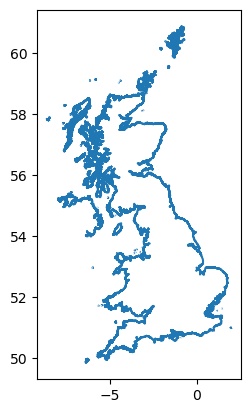

In [4]:
coastlines_gdf[coastlines_gdf.country == "United Kingdom"].plot()


# Load in mpkx file

In [20]:
res = mpkx_loading.process_mpkx(
    config.economics_data_dir / "CR_Fisheries_Shoreline_Protection.mpkx",
    extract_dir=config.economics_data_dir / "test",
    force_reextract=False,
    export_rasters=True,
    save_manifest=True,
)

res["exported_rasters"]
res["manifest_path"]


Using existing extract at /Users/rt582/Library/CloudStorage/OneDrive-UniversityofCambridge/cambridge/phd/Paper_Conferences/reef_cover_economics/data/economics/test
Loading vector layers...
  skipped raster_data.gdb (raster geodatabase not supported)
Discovering rasters...
Exporting rasters to GeoTIFF...
Using existing extract at /Users/rt582/Library/CloudStorage/OneDrive-UniversityofCambridge/cambridge/phd/Paper_Conferences/reef_cover_economics/data/economics/test
Saved manifest -> /Users/rt582/Library/CloudStorage/OneDrive-UniversityofCambridge/cambridge/phd/Paper_Conferences/reef_cover_economics/data/economics/test/mpkx_manifest.json


PosixPath('/Users/rt582/Library/CloudStorage/OneDrive-UniversityofCambridge/cambridge/phd/Paper_Conferences/reef_cover_economics/data/economics/test/mpkx_manifest.json')

## Fisheries catch data

As described in [Modelling Global Coral Reef Fisheries](https://oceanwealth.org/wp-content/uploads/2025/05/Spalding-et-al-Global-Reef-Fisheries-Final-Report.pdf). Units tons/km2/yr.

In [21]:
# open tif
catch_tif = res["exported_rasters"]["predicted_catch"]

# load tif
catch_raster = rasterio.open(catch_tif)
catch_data = catch_raster.read(1)
# plt.hist(catch_data.flatten())    # this shows a random spike at 15 (outside of classes 0-9) which when viewed spatially is clearly an artefact
# plt.yscale("log")

In [22]:
# cast non-zero raster values to points with x/y coordinates in a GeoDataFrame
rows, cols = np.where(catch_data != 0)
xs, ys = rasterio.transform.xy(catch_raster.transform, rows, cols, offset="center")

catch_pts_gdf = gpd.GeoDataFrame(
    {"value": catch_data[rows, cols]},
    geometry=gpd.points_from_xy(xs, ys),
    crs=catch_raster.crs,
).rename(columns=str.lower)
catch_pts_gdf = catch_pts_gdf.to_crs(epsg=4326)
# remove points above value 9
catch_pts_gdf[catch_pts_gdf["value"] == 15] = np.nan
catch_pts_gdf = catch_pts_gdf.dropna()

# TODO: save to a sensible place

In [26]:
# map classes to values (page 15). Currently approximating via median. TODO: replace these with exact calculated values
catch_map = {
    0: 0,
    1: np.median((0.1, 1)),
    2: np.median((1.1, 1.5)),
    3: np.median((1.6, 2)),
    4: np.median((2.1, 2.5)),
    5: np.median((2.6, 3)),
    6: np.median((3.1, 3.5)),
    7: np.median((3.6, 4)),
    8: np.median((4.5, 4.1)),
    9: 4.75,  # this one could be far larger
}

catch_pts_gdf["predicted_catch"] = catch_pts_gdf["value"].map(catch_map)
# assign to countries' EEZs
catch_pts_gdf = processdata.assign_points_to_nations(catch_pts_gdf)

  105,839 points (13.06%) unassigned after within-join; filling nearest…


Assigning nearest country via STRtree-enabled nearest-neighbor search: 100%|██████████| 11/11 [00:23<00:00,  2.13s/it]


  810,182/810,182 points assigned to a nation


/Users/rt582/miniforge3/envs/economics-hbb/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


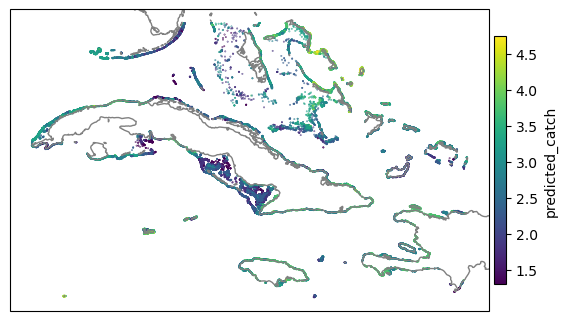

In [24]:
extent = plot_utils.Extent("west_carribbean").as_tuple()

plot_catch_pts_gdf = catch_pts_gdf.cx[extent[0] : extent[2], extent[1] : extent[3]]

fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
# Plot without colorbar
im = plot_catch_pts_gdf.plot(
    ax=ax, column="value", cmap="viridis_r", markersize=0.1, legend=False
)
# Add colorbar manually using matplotlib
sm = plt.cm.ScalarMappable(
    cmap="viridis",
    norm=plt.Normalize(
        vmin=plot_catch_pts_gdf["predicted_catch"].min(),
        vmax=plot_catch_pts_gdf["predicted_catch"].max(),
    ),
)
sm._A = []  # Dummy for colorbar
cbar = plt.colorbar(
    sm, ax=ax, orientation="vertical", fraction=0.025, pad=0.01, label="predicted_catch"
)
# plot_utils.format_geo_axis(ax)
ax.add_feature(cfeature.COASTLINE, color="grey")

In [28]:
# TODO: normalise by gdp due to fisheries in this year (2013) to estimate price (assuming linear relationship) for each class.
# Currently in tons/km2/yr
# This will be incredibly rough

# fish between 2300 to 12000 pounds per tonne. Say $5000 per tonne


PT_AREA = 1  # 1 km2
catch_pts_gdf["catch_revenue"] = catch_pts_gdf["predicted_catch"] * 5000 * PT_AREA
catch_pts_gdf.head()

,value,geometry,predicted_catch,country,iso_a3,catch_revenue
167,2.0,POINT (-64.74048 32.51541),1.3,Bermuda,BMU,6500.0
168,2.0,POINT (-64.73598 32.51541),1.3,Bermuda,BMU,6500.0
169,2.0,POINT (-64.73149 32.51541),1.3,Bermuda,BMU,6500.0
170,2.0,POINT (-64.727 32.51541),1.3,Bermuda,BMU,6500.0
171,2.0,POINT (-64.72251 32.51541),1.3,Bermuda,BMU,6500.0


## Coastal protection data

In [29]:
# this is per decade
cp_gdf = res["vectors"]["GDP_spared_PT"]
cp_gdf = cp_gdf.to_crs(epsg=4326)
cp_gdf

,pointid,grid_code,geometry
0,1,4483,POINT (-64.68657 32.38592)
1,2,4782,POINT (-64.68207 32.38592)
2,3,11476,POINT (-64.67309 32.38592)
3,4,6722,POINT (-64.6686 32.38592)
4,5,139,POINT (-64.69106 32.38059)
...,...,...,...
313482,313483,11,POINT (115.52461 -32.02421)
313483,313484,11,POINT (115.5291 -32.02421)
313484,313485,70,POINT (115.45724 -32.02952)
313485,313486,24,POINT (115.52461 -32.02952)


In [30]:
cp_gdf = res["vectors"][
    "GDP_spared_PT"
]  # US per km of coastline: can just sum these per country
cp_gdf = cp_gdf.to_crs(epsg=4326)
cp_gdf.rename(columns={"grid_code": "GDP_spared_PT"}, inplace=True)
cp_gdf.rename(columns=str.lower, inplace=True)

# assign points to nations
cp_gdf = processdata.assign_points_to_nations(cp_gdf)

  159,066 points (50.74%) unassigned after within-join; filling nearest…


Assigning nearest country via STRtree-enabled nearest-neighbor search: 100%|██████████| 16/16 [00:35<00:00,  2.19s/it]

  313,487/313,487 points assigned to a nation


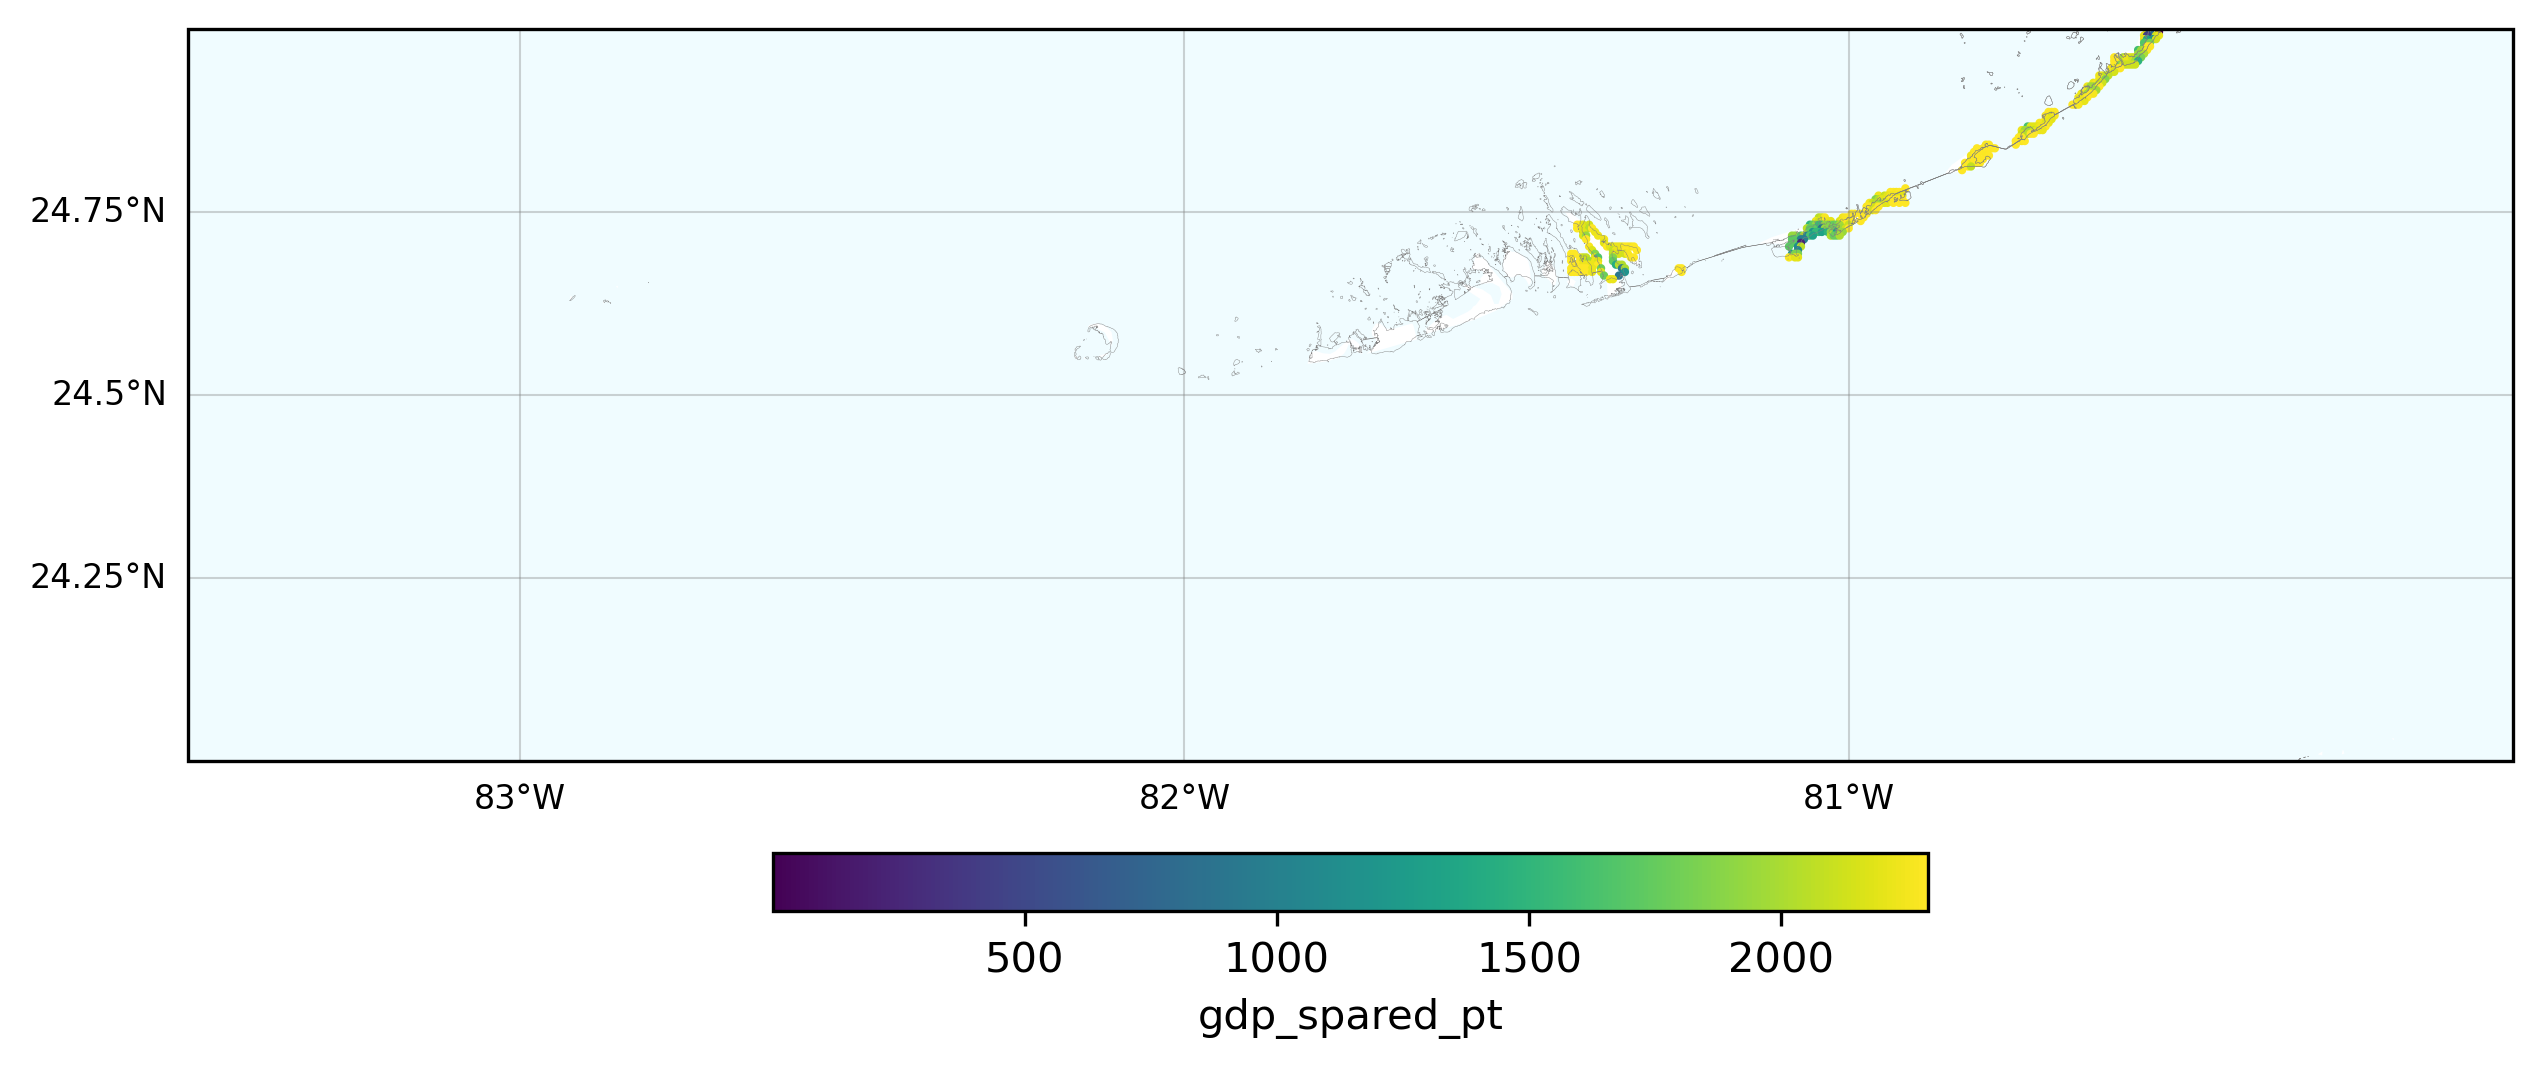

In [ ]:
extent = plot_utils.Extent("key_west").as_tuple()

plot_cp_gdf = cp_gdf[cp_gdf.geometry.intersects(box(*extent))]

local_coastlines = coastlines_gdf.cx[extent[0] : extent[2], extent[1] : extent[3]]

fig, ax = plot_utils.generate_geo_axis()
ax = plot_utils.format_geo_axis(
    ax, xlocs="auto", ylocs="auto", coastlines_gdf=local_coastlines
)

# Plot without colorbar
im = plot_cp_gdf.plot(
    ax=ax,
    column="gdp_spared_pt",
    cmap="viridis_r",
    legend=False,
    markersize=1,
    zorder=1,
)
# Add colorbar manually using matplotlib
sm = plt.cm.ScalarMappable(
    cmap="viridis",
    norm=plt.Normalize(
        vmin=plot_cp_gdf["gdp_spared_pt"].min(),
        vmax=plot_cp_gdf["gdp_spared_pt"].max(),
    ),
)
sm.set_array([])  # Dummy for colorbar
cbar = plt.colorbar(
    sm, ax=ax, orientation="horizontal", fraction=0.025, pad=0.04, label="gdp_spared_pt"
)
ax.set_extent(plot_utils.Extent("key_west").as_extent_tuple())
plt.show()

In [ ]:
# from 'Economic values (GDP - PPP) protected from flooding per decade' dataset at https://maps.oceanwealth.org/#/data
cp_df = pd.DataFrame(
    {
        "value_bin": [
            "0 - 12",
            "13 - 60",
            "61 - 350",
            "351 - 1700",
            "1701 - 10000",
            "10001 - 50000",
            "50001 - 250000",
            "25001 - 1260000",
        ],
        "price_value": [
            np.median((0, 12)),
            np.median((13, 60)),
            np.median((61, 350)),
            np.median((351, 1700)),
            np.median((1701, 10000)),
            np.median((10001, 50000)),
            np.median((50001, 250000)),
            np.median((250001, 1260000)),
        ],
        "price_color": [
            "#ffff82",  # Bin 0
            "#b2f55c",  # Bin 1
            "#5be625",  # Bin 2
            "#41c94a",  # Bin 3
            "#2a82a7",  # Bin 4
            "#294b94",  # Bin 5
            "#c91aff",  # Bin 6
            "#c91aff",  # Bin 7
        ],
    }
)

cp_cmap = ListedColormap(cp_df["price_color"].values)

In [ ]:
plotting.plot_spatial_distribution_interactive(
    plot_cp_gdf,
    bbox=plot_utils.Extent("key_west").as_tuple(),
    plot_column="gdp_spared_pt",
    cmap=cp_cmap,
)

## Tourism data


In [ ]:
prices_df = pd.DataFrame(
    {
        "price_bin": [
            "no value",
            "up to 4000",
            "4001-8000",
            "8001-12000",
            "12001-24000",
            "24001-44000",
            "44001-92000",
            "92001-172000",
            "172001-352000",
            "352001-908000",
            ">908000",
        ],
        "price_value": [
            0,
            np.median((0, 4000)),
            np.median((4001, 8000)),
            np.median((8001, 12000)),
            np.median((12001, 24000)),
            np.median((24001, 44000)),
            np.median((44001, 92000)),
            np.median((92001, 172000)),
            np.median((172001, 352000)),
            np.median((352001, 908000)),
            np.median((908001, 1000000)),
        ],
        "price_color": [
            "#828282",  # Bin 0
            "#2892c8",  # Bin 1
            "#74b474",  # Bin 2
            "#52bf81",  # Bin 3
            "#59d95e",  # Bin 4
            "#58f230",  # Bin 5
            "#f6e058",  # Bin 6
            "#e6ac3e",  # Bin 7
            "#d57726",  # Bin 8
            "#bf4713",  # Bin 9
            "#730000",  # Bin 10
        ],
    }
)

price_cmap = ListedColormap(prices_df["price_color"].values)

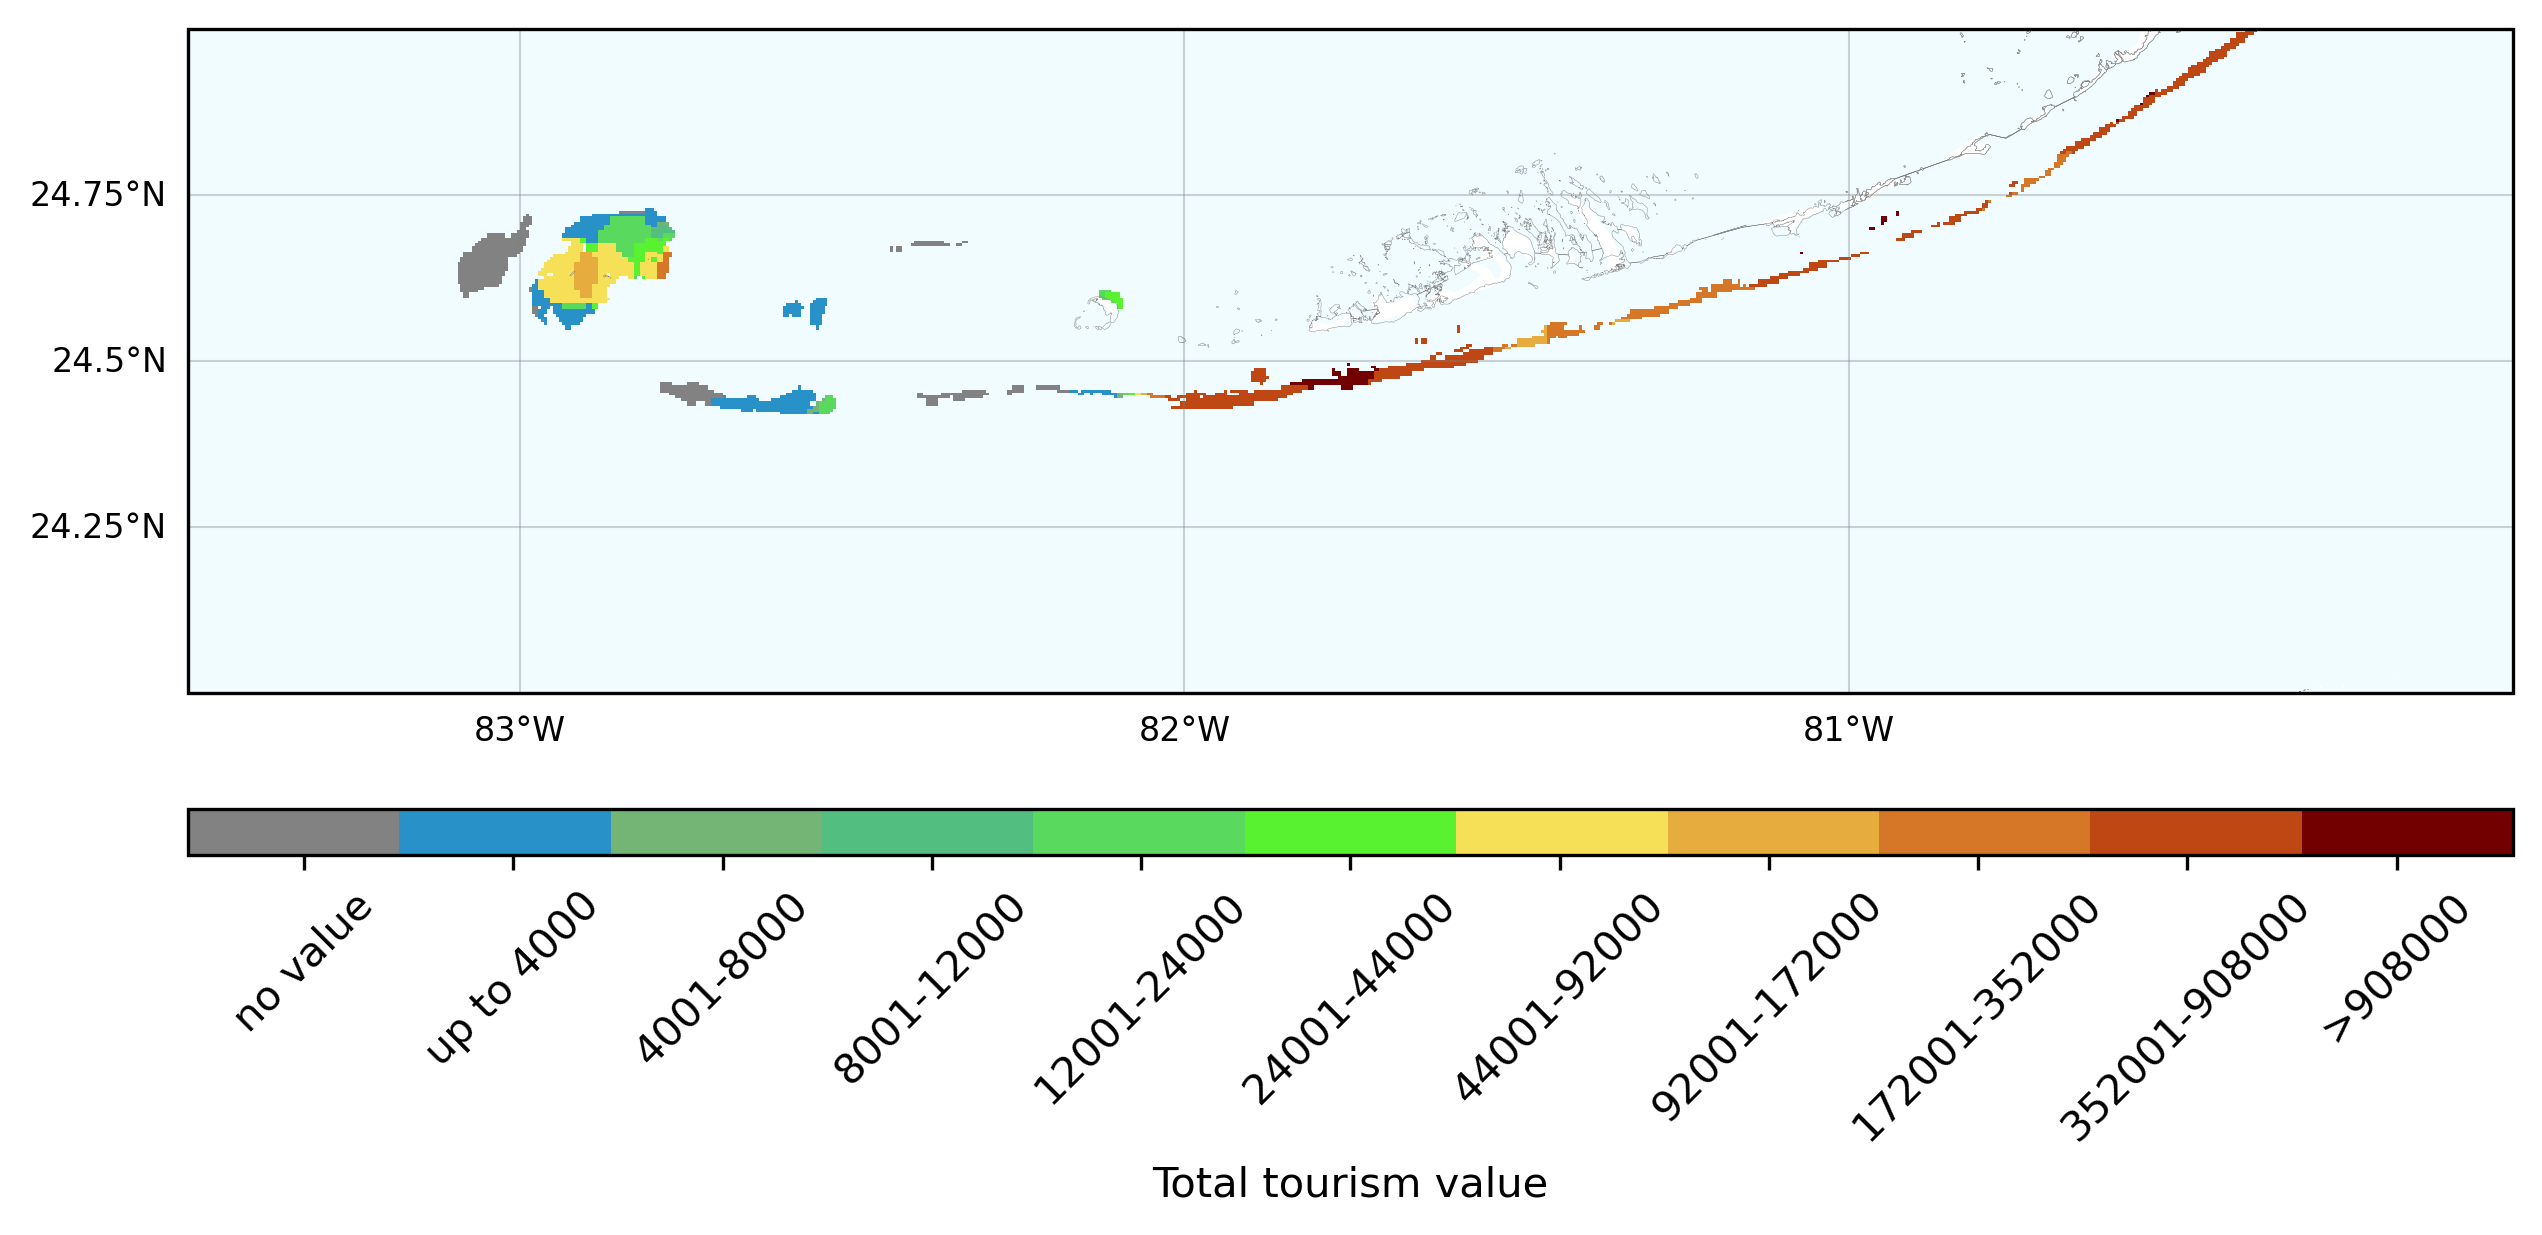

In [63]:
tourism_gdp_gdf = (
    gpd.read_file(
        config.tourism_dir
        / "total"
        / "Coral_Reef_Tourism_Global_Total_Dollar_Value.shp"
    )
    .to_crs(epsg=4326)
    .rename(columns=str.lower)
)


tourism_gdp_gdf["total_reef_value"] = prices_df["price_value"]
tourism_gdp_gdf["approx_price"] = prices_df["price_value"]

# plot example for florida
fig, ax = plot_utils.generate_geo_axis()
ax = plot_utils.format_geo_axis(ax, coastlines_gdf=local_coastlines)

extent = plot_utils.Extent("key_west").as_tuple()

plot_tourism_gdf = tourism_gdp_gdf[tourism_gdp_gdf.geometry.intersects(box(*extent))]

collection = plot_tourism_gdf.plot(
    ax=ax,
    column="bin_global",
    cmap=price_cmap,
    legend=False,  # will create custom legend later
    linewidth=0.2,
    edgecolor=None,
)

norm = Normalize(
    vmin=plot_tourism_gdf["bin_global"].min(),
    vmax=plot_tourism_gdf["bin_global"].max(),
)
sm = cm.ScalarMappable(cmap=price_cmap, norm=norm)
sm.set_array([])
cb = fig.colorbar(
    sm,
    ax=ax,
    label="Total tourism value",
    orientation="horizontal",
    pad=0.05,
    aspect=50,
    ticks=np.linspace(0.5, 9.5, len(prices_df["price_value"])),
)
cb.set_ticklabels(prices_df["price_bin"])
cb.ax.tick_params(rotation=45)
# zooming in to compare with the maps online at (Data Layers for Global Recreation and Tourism Coral Reefs) for Ocean Wealth
ax.set_extent(plot_utils.Extent("key_west").as_extent_tuple())
plt.show()

In [72]:
# start by exploding multi-part polygons
tourism_gdp_gdf_exploded = tourism_gdp_gdf.explode(index_parts=False).reset_index(
    drop=True
)
# assign points to nations
tourism_gdp_gdf_exploded = processdata.assign_points_to_nations(
    tourism_gdp_gdf_exploded
)

  26,971 points (42.69%) unassigned after within-join; filling nearest…


Assigning nearest country via STRtree-enabled nearest-neighbor search: 100%|██████████| 3/3 [00:27<00:00,  9.11s/it]

  63,181/63,181 points assigned to a nation


In [76]:
tourism_gdp_gdf_exploded


,bin_global,sum_gridco,sum_no_cel,sum_sq_km,shape_leng,shape_area,total_reef_value,approx_price,geometry,country,iso_a3
0,0,0.0,750980.0,187745.00,382060000.0,1.877450e+11,0.0,0.0,"POLYGON ((159.08259 -29.90106, 159.08259 -29.9...",Australia,AUS
1,0,0.0,750980.0,187745.00,382060000.0,1.877450e+11,0.0,0.0,"POLYGON ((159.12751 -29.42099, 159.12751 -29.4...",Australia,AUS
2,0,0.0,750980.0,187745.00,382060000.0,1.877450e+11,0.0,0.0,"POLYGON ((113.90182 -28.8836, 113.90182 -28.87...",Australia,AUS
3,0,0.0,750980.0,187745.00,382060000.0,1.877450e+11,0.0,0.0,"POLYGON ((114.01411 -28.86393, 114.01411 -28.8...",Australia,AUS
4,0,0.0,750980.0,187745.00,382060000.0,1.877450e+11,0.0,0.0,"POLYGON ((114.04555 -28.78917, 114.04555 -28.7...",Australia,AUS
...,...,...,...,...,...,...,...,...,...,...,...
63175,10,17244398.0,33383.0,8345.75,22998000.0,8.345750e+09,954000.5,954000.5,"POLYGON ((-64.72817 32.35622, -64.72817 32.352...",Bermuda,BMU
63176,10,17244398.0,33383.0,8345.75,22998000.0,8.345750e+09,954000.5,954000.5,"POLYGON ((-64.74614 32.37519, -64.73715 32.375...",Bermuda,BMU
63177,10,17244398.0,33383.0,8345.75,22998000.0,8.345750e+09,954000.5,954000.5,"POLYGON ((-64.74614 32.37519, -64.75512 32.375...",Bermuda,BMU
63178,10,17244398.0,33383.0,8345.75,22998000.0,8.345750e+09,954000.5,954000.5,"POLYGON ((-64.68326 32.38277, -64.68326 32.378...",Bermuda,BMU


In [77]:
plotting.plot_spatial_distribution_interactive(
    tourism_gdp_gdf_exploded,
    bbox=plot_utils.Extent("key_west").as_tuple(),
    plot_column="bin_global",
    cmap=price_cmap,
)


# Unifying datasets

In [ ]:
# TODO: work out how to merge point and polygon data for each country. I think it's simple: just more difficult to visualise spatially (may have to superpose the datasets)
# All that really matters is that I can get an aggregate by country